In [1]:
# === Configuration ===
import os
# === Load raw dataset ===
from pathlib import Path
import pandas as pd

DATA_PATH = Path("data_input/political/news_article_dataset.json")
assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"

df = pd.read_json(DATA_PATH, lines=True)
df.shape


(8478, 14)

In [2]:
import sys
sys.path.append("helpers")
import prompts


In [3]:
MIN_LEN = 590

df_clean = df[
    df["left_story_text"].notna() &
    df["center_story_text"].notna() &
    df["right_story_text"].notna() &
    (df["left_story_text"].str.len() > MIN_LEN) &
    (df["center_story_text"].str.len() > MIN_LEN) &
    (df["right_story_text"].str.len() > MIN_LEN)
]

len(df_clean)


219

In [4]:
SEED = 40
df_sample = df_clean.sample(50, random_state=SEED)


In [5]:
records = []

for _, row in df_sample.iterrows():
    event = row["Title of Headline Roundup"]

    records.append({
        "event": event,
        "ideology": "liberal",
        "text": row["left_story_text"]
    })

    records.append({
        "event": event,
        "ideology": "center",
        "text": row["center_story_text"]
    })

    records.append({
        "event": event,
        "ideology": "conservative",
        "text": row["right_story_text"]
    })

final_df = pd.DataFrame(records)
final_df.shape
final_df = final_df.dropna(subset=["text"]).reset_index(drop=True)
assert final_df["text"].notna().all()  # ma wyjść 0

In [6]:
final_df["ideology"].value_counts()

ideology
liberal         50
center          50
conservative    50
Name: count, dtype: int64

In [7]:
final_df["text"].str.len().describe()

count    150.000000
mean     620.813333
std       23.540166
min      591.000000
25%      602.000000
50%      617.000000
75%      633.000000
max      721.000000
Name: text, dtype: float64

In [8]:
final_df["event"].nunique()
len(final_df)

150

In [9]:
final_df.to_csv(
    "data_processed/political_3way_50events.csv",
    index=False
)

In [10]:
from pathlib import Path

base = Path("data_input")

dirs = {
    "center": base / "center",
    "liberal": base / "liberal",
    "conservative": base / "conservative"
}

for d in dirs.values():
    d.mkdir(parents=True, exist_ok=True)

In [11]:
for d in dirs.values():
    for p in d.glob("*.txt"):
        p.unlink()


In [12]:
for i, row in final_df.iterrows():
    ideology = row["ideology"]
    text = row["text"]

    out = dirs[ideology] / f"doc_{i:03d}.txt"
    out.write_text(text, encoding="utf-8")


In [13]:
for k, d in dirs.items():
    print(k, len(list(d.glob("*.txt"))))


center 50
liberal 50
conservative 50


In [14]:
import pandas as pd
import networkx as nx
from pathlib import Path

# Jupyter jest w knowledge_graph/
BASE = Path("data_output")

IDEOLOGIES = ["liberal", "center", "conservative"]


In [15]:
for ideology in IDEOLOGIES:
    graph_path = BASE / ideology / "graph.csv"
    chunks_path = BASE / ideology / "chunks.csv"

    print(
        f"{ideology:13s} | "
        f"graph.csv: {graph_path.exists()} | "
        f"chunks.csv: {chunks_path.exists()}"
    )

liberal       | graph.csv: True | chunks.csv: True
center        | graph.csv: True | chunks.csv: True
conservative  | graph.csv: True | chunks.csv: True


In [16]:
graphs_df = {}
chunks_df = {}

for ideology in IDEOLOGIES:
    graphs_df[ideology] = pd.read_csv(BASE / ideology / "graph.csv", sep="|")
    chunks_df[ideology] = pd.read_csv(BASE / ideology / "chunks.csv", sep="|")

{ideology: (graphs_df[ideology].shape, chunks_df[ideology].shape)
 for ideology in IDEOLOGIES}

{'liberal': ((187, 4), (50, 3)),
 'center': ((180, 4), (50, 3)),
 'conservative': ((187, 4), (50, 3))}

In [17]:
def build_graph_with_support(df_graph, min_support=1):
    tmp = df_graph.copy()
    tmp["u"] = tmp["node_1"].astype(str)
    tmp["v"] = tmp["node_2"].astype(str)
    tmp["edge_key"] = tmp.apply(
        lambda r: tuple(sorted((r["u"], r["v"]))), axis=1
    )

    support = (
        tmp.groupby("edge_key")["chunk_id"]
        .nunique()
        .reset_index(name="support")
    )

    keep = support[support["support"] >= min_support]

    G = nx.Graph()
    for _, r in keep.iterrows():
        u, v = r["edge_key"]
        G.add_edge(u, v, support=int(r["support"]))
    return G


graphs = {}
for ideology in IDEOLOGIES:
    graphs[ideology] = build_graph_with_support(
        graphs_df[ideology],
        min_support=1
    )

{ideology: (graphs[ideology].number_of_nodes(),
            graphs[ideology].number_of_edges())
 for ideology in IDEOLOGIES}


{'liberal': (244, 179), 'center': (241, 179), 'conservative': (255, 185)}

In [18]:
SUPPORT_LEVELS = [1, 2, 3, 4, 5]
pairs = [("liberal", "conservative"), ("liberal", "center"), ("center", "conservative")]

graphs_by_support = {s: {} for s in SUPPORT_LEVELS}
for s in SUPPORT_LEVELS:
    for ideology in IDEOLOGIES:
        graphs_by_support[s][ideology] = build_graph_with_support(
            graphs_df[ideology],
            min_support=s
        )

# podgląd rozmiarów grafów dla każdej konfiguracji
{
    s: {ideology: (graphs_by_support[s][ideology].number_of_nodes(),
                  graphs_by_support[s][ideology].number_of_edges())
        for ideology in IDEOLOGIES}
    for s in SUPPORT_LEVELS
}


{1: {'liberal': (244, 179), 'center': (241, 179), 'conservative': (255, 185)},
 2: {'liberal': (2, 1), 'center': (0, 0), 'conservative': (2, 1)},
 3: {'liberal': (0, 0), 'center': (0, 0), 'conservative': (0, 0)},
 4: {'liberal': (0, 0), 'center': (0, 0), 'conservative': (0, 0)},
 5: {'liberal': (0, 0), 'center': (0, 0), 'conservative': (0, 0)}}

In [19]:
def compute_node_support(df):
    nodes = pd.concat([
        df[["node_1", "chunk_id"]].rename(columns={"node_1": "node"}),
        df[["node_2", "chunk_id"]].rename(columns={"node_2": "node"}),
    ])
    nodes["node"] = nodes["node"].astype(str).str.lower().str.strip()
    return (
        nodes.groupby("node")["chunk_id"]
        .nunique()
        .sort_values(ascending=False)
    )

node_supports = {ideology: compute_node_support(graphs_df[ideology])
                 for ideology in IDEOLOGIES}

node_supports["liberal"].head(10)


node
russia                        3
president joe biden           3
biden administration          3
justice department            2
google                        2
covid-19 pandemic             2
democrats                     2
trump                         2
afghan government             2
plane-helicopter collision    1
Name: chunk_id, dtype: int64

In [20]:
def build_graph_node_filtered(df_graph, allowed_nodes):
    tmp = df_graph.copy()
    tmp["u"] = tmp["node_1"].astype(str).str.lower().str.strip()
    tmp["v"] = tmp["node_2"].astype(str).str.lower().str.strip()

    tmp = tmp[
        tmp["u"].isin(allowed_nodes) &
        tmp["v"].isin(allowed_nodes)
    ]

    G = nx.Graph()
    for _, r in tmp.iterrows():
        G.add_edge(r["u"], r["v"])
    return G


In [21]:
graphs_node_configs = {}

for ideology in IDEOLOGIES:
    ns = node_supports[ideology]

    graphs_node_configs[(ideology, "all")] = build_graph_node_filtered(
        graphs_df[ideology], set(ns.index)
    )

    graphs_node_configs[(ideology, "support>=2")] = build_graph_node_filtered(
        graphs_df[ideology], set(ns[ns >= 2].index)
    )

    graphs_node_configs[(ideology, "top50")] = build_graph_node_filtered(
        graphs_df[ideology], set(ns.head(50).index)
    )

{
    k: (v.number_of_nodes(), v.number_of_edges())
    for k, v in graphs_node_configs.items()
}


{('liberal', 'all'): (244, 179),
 ('liberal', 'support>=2'): (2, 1),
 ('liberal', 'top50'): (13, 7),
 ('center', 'all'): (241, 179),
 ('center', 'support>=2'): (11, 7),
 ('center', 'top50'): (20, 13),
 ('conservative', 'all'): (255, 185),
 ('conservative', 'support>=2'): (11, 10),
 ('conservative', 'top50'): (19, 15)}

In [22]:
def jaccard_nodes(G1, G2):
    V1, V2 = set(G1.nodes()), set(G2.nodes())
    return len(V1 & V2) / len(V1 | V2) if (V1 or V2) else 0.0

rows = []
for config in ["all", "support>=2", "top50"]:
    rows.append({
        "config": config,
        "liberal vs conservative": jaccard_nodes(
            graphs_node_configs[("liberal", config)],
            graphs_node_configs[("conservative", config)]
        ),
        "liberal vs center": jaccard_nodes(
            graphs_node_configs[("liberal", config)],
            graphs_node_configs[("center", config)]
        ),
        "center vs conservative": jaccard_nodes(
            graphs_node_configs[("center", config)],
            graphs_node_configs[("conservative", config)]
        ),
    })

pd.DataFrame(rows)
df_jaccard_nodes = pd.DataFrame(rows).round(3)
df_jaccard_nodes

,config,liberal vs conservative,liberal vs center,center vs conservative
0,all,0.078,0.071,0.078
1,support>=2,0.182,0.083,0.222
2,top50,0.103,0.100,0.182


In [23]:
def jaccard_edges(G1, G2):
    # edges as unordered pairs (u,v) to be consistent for undirected graphs
    E1 = {tuple(sorted(e)) for e in G1.edges()}
    E2 = {tuple(sorted(e)) for e in G2.edges()}
    return len(E1 & E2) / len(E1 | E2) if (E1 or E2) else 0.0

rows = []
for config in ["all", "support>=2", "top50"]:
    rows.append({
        "config": config,
        "liberal vs conservative": jaccard_edges(
            graphs_node_configs[("liberal", config)],
            graphs_node_configs[("conservative", config)]
        ),
        "liberal vs center": jaccard_edges(
            graphs_node_configs[("liberal", config)],
            graphs_node_configs[("center", config)]
        ),
        "center vs conservative": jaccard_edges(
            graphs_node_configs[("center", config)],
            graphs_node_configs[("conservative", config)]
        ),
    })

pd.DataFrame(rows)
df_jaccard_edges = pd.DataFrame(rows).round(3)
df_jaccard_edges


,config,liberal vs conservative,liberal vs center,center vs conservative
0,all,0.011,0.008,0.011
1,support>=2,0.100,0.000,0.000
2,top50,0.048,0.000,0.000


In [24]:
import pandas as pd

events_df = pd.read_csv("data_processed/political_3way_50events.csv")

# To jest docelowe "texts_df" do Moral Foundations:
texts_df = events_df.copy()

print(texts_df.shape)
print(texts_df.columns)
texts_df.head(3)


(150, 3)
Index(['event', 'ideology', 'text'], dtype='object')


,event,ideology,text
0,Iranian President Raisi Killed in Helicopter C...,liberal,Iranian President Ebrahim Raisi and his foreig...
1,Iranian President Raisi Killed in Helicopter C...,center,Iranian President Ebrahim Raisi was killed in ...
2,Iranian President Raisi Killed in Helicopter C...,conservative,"Iranian president Ebrahim Raisi, Foreign Minis..."


In [25]:
import re, prompts
p = prompts.MF_PROMPT_EN
print("single { count:", len(re.findall(r"(?<!{){(?!{)", p)))
print("single } count:", len(re.findall(r"(?<!})}(?!})", p)))


single { count: 1
single } count: 1


In [26]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import prompts

OUTPUT_PATH = Path("data_output/mf_scores_articles.csv")
MF_MODEL = "zephyr:latest"

# 1) Cache
if OUTPUT_PATH.exists():
    print(f"Loading cached MF scores from {OUTPUT_PATH}")
    mf_df = pd.read_csv(OUTPUT_PATH)

else:
    print("Computing Moral Foundations scores with LLM...")
    mf_rows = []
    bad = 0

    for i, (_, r) in enumerate(tqdm(texts_df.iterrows(), total=len(texts_df)), start=1):

        # (opcjonalne) debug print — zostaw jeśli chcesz
        print("\n" + "="*120)
        print(f"[{i}/{len(texts_df)}]")
        print(f"EVENT    : {r['event']}")
        print(f"IDEOLOGY : {r['ideology']}")
        print("-"*120)
        # print(r["text"])   # jeśli za dużo spamu, zakomentuj
        print("-"*120)

        try:
            scores = prompts.moralFoundations(
                text=r["text"],
                metadata={"event": r["event"], "ideology": r["ideology"]},
                model=MF_MODEL,
            )

            if scores is None:
                bad += 1
                continue

            # 2) Zawsze dopisz metadane do wyniku (żeby mf_df było samowystarczalne)
            scores["event"] = r["event"]
            scores["ideology"] = r["ideology"]

            mf_rows.append(scores)

            # (opcjonalne) debug print
            print("MF SCORES:", scores)

        except Exception as e:
            bad += 1
            print("ERROR:", repr(e))

    mf_df = pd.DataFrame(mf_rows)
    mf_df.to_csv(OUTPUT_PATH, index=False)
    print(f"Saved MF scores to {OUTPUT_PATH}")
    print("bad:", bad)

mf_df.head()


Loading cached MF scores from data_output/mf_scores_articles.csv


,care_harm,fairness_cheating,loyalty_betrayal,authority_subversion,sanctity_degradation,liberty_oppression,event,ideology
0,8,0,0,0,0,0,Iranian President Raisi Killed in Helicopter C...,liberal
1,0,0,0,0,0,0,Iranian President Raisi Killed in Helicopter C...,center
2,8,0,5,5,0,0,Iranian President Raisi Killed in Helicopter C...,conservative
3,0,2,8,5,0,0,Trump Compares Biden Administration to ‘Gestap...,liberal
4,0,0,0,8,0,0,Trump Compares Biden Administration to ‘Gestap...,center


In [27]:
import sys
!{sys.executable} -m pip install -q scikit-learn


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
matplotlib 3.8.1 requires numpy<2,>=1.21, but you have numpy 2.4.2 which is incompatible.
pandas 2.1.3 requires numpy<2,>=1.23.2; python_version == "3.11", but you have numpy 2.4.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.2 which is incompatible.
langchain 0.0.335 requires numpy<2,>=1, but you have numpy 2.4.2 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [28]:
import sys

!{sys.executable} -m pip uninstall -y -q numpy scipy scikit-learn matplotlib
!{sys.executable} -m pip install -q --no-cache-dir "numpy==1.26.4" "scipy==1.11.4" "scikit-learn==1.4.2" "matplotlib==3.8.4"



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [29]:
import numpy as np, scipy, sklearn, matplotlib
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)


numpy: 1.26.2
scipy: 1.11.4
sklearn: 1.4.2
matplotlib: 3.8.4


Loaded: (150, 8)
Columns: ['care_harm', 'fairness_cheating', 'loyalty_betrayal', 'authority_subversion', 'sanctity_degradation', 'liberty_oppression', 'event', 'ideology']


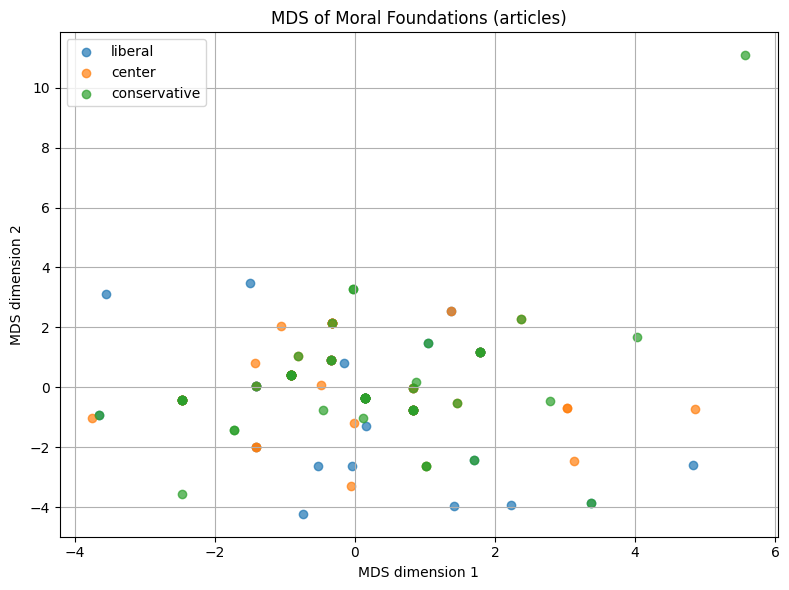

Saved plot to: data_output/mds_moral_foundations.png


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

# =========================
# 0. Wczytanie danych
# =========================
CSV_PATH = "data_output/mf_scores_articles.csv"
mf_df = pd.read_csv(CSV_PATH)

print("Loaded:", mf_df.shape)
print("Columns:", mf_df.columns.tolist())

# =========================
# 1. Kolumny Moral Foundations
# =========================
mf_cols = [
    "care_harm",
    "fairness_cheating",
    "loyalty_betrayal",
    "authority_subversion",
    "sanctity_degradation",
    "liberty_oppression",
]

# =========================
# 2. Macierz danych (150 x 6)
# =========================
X = mf_df[mf_cols].fillna(0).values

# (opcjonalnie, ale zalecane) standaryzacja
X = StandardScaler().fit_transform(X)

# =========================
# 3. MDS -> 2D
# =========================
mds = MDS(
    n_components=2,
    random_state=42,
    dissimilarity="euclidean",
    n_init=4,
    max_iter=300,
)
X_mds = mds.fit_transform(X)

# =========================
# 4. Wykres (kolor = ideologia)
# =========================
plt.figure(figsize=(8, 6))

for ideology in mf_df["ideology"].unique():
    mask = mf_df["ideology"] == ideology
    plt.scatter(
        X_mds[mask, 0],
        X_mds[mask, 1],
        label=ideology,
        alpha=0.7,
    )

plt.title("MDS of Moral Foundations (articles)")
plt.xlabel("MDS dimension 1")
plt.ylabel("MDS dimension 2")
plt.legend()
plt.grid(True)

# ZAPIS DO PLIKU (ważne do slajdów)
OUT_PATH = "data_output/mds_moral_foundations.png"
plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200)
plt.show()

print("Saved plot to:", OUT_PATH)


In [31]:
import importlib
import pandas as pd
import prompts
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

importlib.reload(prompts)


<module 'prompts' from '/app/helpers/prompts.py'>

In [32]:
df = pd.read_csv("data_output/mf_scores_articles.csv")
df_bin = df[df["ideology"].isin(["liberal", "conservative"])].copy()

print(df_bin["ideology"].value_counts())


ideology
liberal         50
conservative    50
Name: count, dtype: int64


In [33]:
import io
import contextlib

preds = []
confs = []
total = len(df_bin)

for i, (_, r) in enumerate(df_bin.iterrows(), start=1):
    print(f"[{i}/{total}] klasyfikacja artykułu...")

    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        out = prompts.classifyIdeologyFromMF(
            care_harm=r["care_harm"],
            fairness_cheating=r["fairness_cheating"],
            loyalty_betrayal=r["loyalty_betrayal"],
            authority_subversion=r["authority_subversion"],
            sanctity_degradation=r["sanctity_degradation"],
            liberty_oppression=r["liberty_oppression"],
            metadata={"event": r.get("event", None)},
            model="zephyr:latest",
        )

    if out is None:
        preds.append("unknown")
        confs.append(0)
    else:
        preds.append(out["predicted_ideology"])
        confs.append(out["confidence"])

df_bin["predicted_ideology"] = preds
df_bin["confidence"] = confs


[1/100] klasyfikacja artykułu...
[2/100] klasyfikacja artykułu...
[3/100] klasyfikacja artykułu...
[4/100] klasyfikacja artykułu...
[5/100] klasyfikacja artykułu...
[6/100] klasyfikacja artykułu...
[7/100] klasyfikacja artykułu...
[8/100] klasyfikacja artykułu...
[9/100] klasyfikacja artykułu...
[10/100] klasyfikacja artykułu...
[11/100] klasyfikacja artykułu...
[12/100] klasyfikacja artykułu...
[13/100] klasyfikacja artykułu...
[14/100] klasyfikacja artykułu...
[15/100] klasyfikacja artykułu...
[16/100] klasyfikacja artykułu...
[17/100] klasyfikacja artykułu...
[18/100] klasyfikacja artykułu...
[19/100] klasyfikacja artykułu...
[20/100] klasyfikacja artykułu...
[21/100] klasyfikacja artykułu...
[22/100] klasyfikacja artykułu...
[23/100] klasyfikacja artykułu...
[24/100] klasyfikacja artykułu...
[25/100] klasyfikacja artykułu...
[26/100] klasyfikacja artykułu...
[27/100] klasyfikacja artykułu...
[28/100] klasyfikacja artykułu...
[29/100] klasyfikacja artykułu...
[30/100] klasyfikacja a

In [34]:
df_eval = df_bin[df_bin["predicted_ideology"].isin(["liberal", "conservative"])]

print("Evaluated:", len(df_eval), "/", len(df_bin))
print("Accuracy:", accuracy_score(df_eval["ideology"], df_eval["predicted_ideology"]))
print("Confusion matrix:\n", confusion_matrix(df_eval["ideology"], df_eval["predicted_ideology"]))
print("\nReport:\n", classification_report(df_eval["ideology"], df_eval["predicted_ideology"]))

print("Mean confidence:", df_eval["confidence"].mean())


Evaluated: 93 / 100
Accuracy: 0.5913978494623656
Confusion matrix:
 [[25 22]
 [16 30]]

Report:
               precision    recall  f1-score   support

conservative       0.61      0.53      0.57        47
     liberal       0.58      0.65      0.61        46

    accuracy                           0.59        93
   macro avg       0.59      0.59      0.59        93
weighted avg       0.59      0.59      0.59        93

Mean confidence: 7.956989247311828
